In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost

print("Environment ready!")
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)

Environment ready!
Pandas: 2.2.3
Scikit-learn: 1.6.1
XGBoost: 3.4.1


In [2]:
import os

os.makedirs("/content/fraud_data", exist_ok=True)

print("Dataset folder created!")

Dataset folder created!


In [7]:
import os

os.listdir("/content/fraud_data")

['train_transaction.csv',
 'ieee-fraud-detection.zip',
 'test_identity.csv',
 'sample_submission.csv',
 'test_transaction.csv',
 'train_identity.csv']

In [8]:
import pandas as pd
import numpy as np

data_path = "/content/fraud_data/"

transaction_cols = [
    "TransactionID", "isFraud", "TransactionDT", "TransactionAmt",
    "ProductCD",
    "card1", "card2", "card3", "card4", "card5", "card6",
    "addr1", "addr2",
    "dist1", "dist2",
    "P_emaildomain", "R_emaildomain",
    "C1", "C2", "C3", "C4", "C5", "C6",
    "C7", "C8", "C9", "C10", "C11", "C12", "C13", "C14"
]

train = pd.read_csv(
    data_path + "train_transaction.csv",
    usecols=transaction_cols
)

identity_cols = [
    "TransactionID",
    "DeviceType",
    "DeviceInfo",
    "id_12", "id_13", "id_15", "id_16",
    "id_17", "id_18", "id_19", "id_20",
    "id_21", "id_22", "id_23", "id_24",
    "id_25", "id_26"
]

identity = pd.read_csv(
    data_path + "train_identity.csv",
    usecols=identity_cols
)

print("Transaction:", train.shape)
print("Identity:", identity.shape)

Transaction: (590540, 31)
Identity: (144233, 17)


In [9]:
# Merge transaction + identity data
df = train.merge(
    identity,
    on="TransactionID",
    how="left"
)

# Reduce memory usage
for col in df.select_dtypes(include=["float64"]).columns:
    df[col] = df[col].astype("float32")

for col in df.select_dtypes(include=["int64"]).columns:
    df[col] = df[col].astype("int32")

print("Final dataset shape:", df.shape)
print("\nMemory usage (MB):",
      round(df.memory_usage(deep=True).sum() / 1024**2, 2))

Final dataset shape: (590540, 47)

Memory usage (MB): 346.7


In [10]:
from sklearn.model_selection import train_test_split

# Separate target
y = df["isFraud"]
X = df.drop(columns=["isFraud"])

# Split while preserving the fraud ratio
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape, y_train.shape)
print("Testing:", X_test.shape, y_test.shape)

print("\nFraud rate - Training:", round(y_train.mean(), 4))
print("Fraud rate - Testing:", round(y_test.mean(), 4))

Training: (472432, 46) (472432,)
Testing: (118108, 46) (118108,)

Fraud rate - Training: 0.035
Fraud rate - Testing: 0.035


In [11]:
# Find categorical columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Categorical columns:", len(categorical_cols))
print(categorical_cols)

Categorical columns: 11
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'id_12', 'id_15', 'id_16', 'id_23', 'DeviceType', 'DeviceInfo']


In [12]:
# Fill missing categorical values
X_train[categorical_cols] = X_train[categorical_cols].fillna("Missing")
X_test[categorical_cols] = X_test[categorical_cols].fillna("Missing")

print("Categorical missing values handled.")

Categorical missing values handled.


In [13]:
from sklearn.preprocessing import OrdinalEncoder

# Create encoder
encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

# Fit only on training data
X_train[categorical_cols] = encoder.fit_transform(
    X_train[categorical_cols]
)

# Transform test data
X_test[categorical_cols] = encoder.transform(
    X_test[categorical_cols]
)

print("Categorical encoding completed!")
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Categorical encoding completed!
Training shape: (472432, 46)
Testing shape: (118108, 46)


In [14]:
# Find numeric columns
numeric_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

# Fill missing numeric values using training medians
medians = X_train[numeric_cols].median()

X_train[numeric_cols] = X_train[numeric_cols].fillna(medians)
X_test[numeric_cols] = X_test[numeric_cols].fillna(medians)

print("Numeric missing values handled!")
print("Missing in training:", X_train.isnull().sum().sum())
print("Missing in testing:", X_test.isnull().sum().sum())

Numeric missing values handled!
Missing in training: 0
Missing in testing: 0


In [15]:
from xgboost import XGBClassifier

# Handle class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=2
)

print("Scale pos weight:", round(scale_pos_weight, 2))
print("Model ready!")

Scale pos weight: 27.58
Model ready!


In [16]:
# Train XGBoost
print("Training started...")

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("Training completed!")

Training started...
[0]	validation_0-aucpr:0.26414
[50]	validation_0-aucpr:0.52765
[100]	validation_0-aucpr:0.56960
[150]	validation_0-aucpr:0.59614
[200]	validation_0-aucpr:0.61952
[250]	validation_0-aucpr:0.63891
[299]	validation_0-aucpr:0.65632
Training completed!


In [17]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Fraud probabilities
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Default threshold
y_pred = (y_pred_proba >= 0.5).astype(int)

# Metrics
roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("ROC-AUC :", round(roc_auc, 4))
print("PR-AUC  :", round(pr_auc, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

ROC-AUC : 0.9441
PR-AUC  : 0.6564
Precision: 0.2554
Recall   : 0.8195
F1 Score : 0.3895

Confusion Matrix:
[[104102   9873]
 [   746   3387]]


In [18]:
import numpy as np
from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, thresholds = precision_recall_curve(
    y_test,
    y_pred_proba
)

f1_scores = (
    2 * precision_vals[:-1] * recall_vals[:-1]
    / (precision_vals[:-1] + recall_vals[:-1] + 1e-10)
)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold:", round(best_threshold, 4))
print("Best precision:", round(precision_vals[best_idx], 4))
print("Best recall:", round(recall_vals[best_idx], 4))
print("Best F1:", round(f1_scores[best_idx], 4))

Best threshold: 0.8294
Best precision: 0.7039
Best recall: 0.5621
Best F1: 0.6251


In [19]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top 15 features:")
print(importance.head(15))

Top 15 features:
C8               0.126308
R_emaildomain    0.070312
C14              0.066307
C5               0.065622
C4               0.056652
C12              0.053359
card6            0.045890
C1               0.037724
C2               0.030123
id_17            0.025570
id_12            0.025297
C6               0.025108
C9               0.024826
ProductCD        0.024335
C13              0.023910
dtype: float32


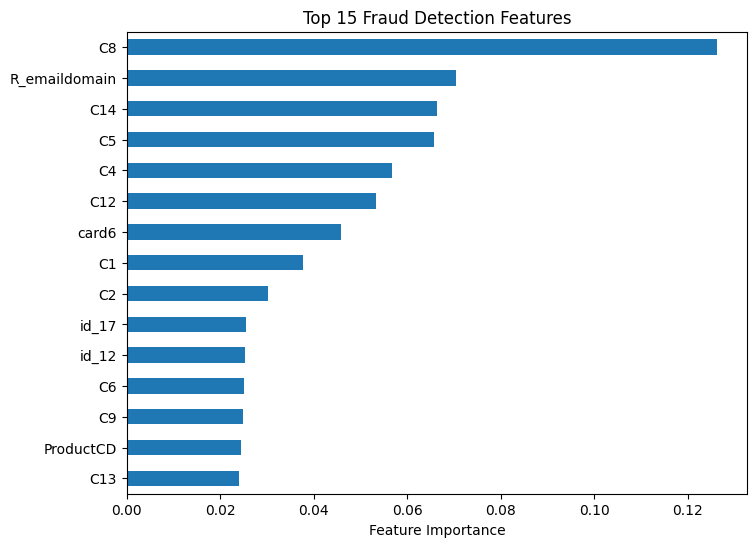

In [20]:
importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8, 6)
)

plt.title("Top 15 Fraud Detection Features")
plt.xlabel("Feature Importance")
plt.show()

In [21]:
import joblib
import os

# Create folder for saved model
os.makedirs("/content/fraud_model", exist_ok=True)

# Save trained model
joblib.dump(model, "/content/fraud_model/fraud_model.pkl")

# Save encoder
joblib.dump(encoder, "/content/fraud_model/encoder.pkl")

# Save selected feature names
joblib.dump(X_train.columns.tolist(), "/content/fraud_model/features.pkl")

print("Model and preprocessing objects saved successfully!")
print(os.listdir("/content/fraud_model"))

Model and preprocessing objects saved successfully!
['features.pkl', 'encoder.pkl', 'fraud_model.pkl']


In [22]:
from sklearn.metrics import confusion_matrix, classification_report

# Predict probabilities on test data
y_prob = model.predict_proba(X_test)[:, 1]

# Use the best threshold found earlier
best_threshold = 0.8294

# Convert probabilities to fraud / non-fraud
y_pred_best = (y_prob >= best_threshold).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

print("Threshold:", best_threshold)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_best,
    target_names=["Not Fraud", "Fraud"]
))

Threshold: 0.8294

Confusion Matrix:
[[112998    977]
 [  1812   2321]]

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       0.98      0.99      0.99    113975
       Fraud       0.70      0.56      0.62      4133

    accuracy                           0.98    118108
   macro avg       0.84      0.78      0.81    118108
weighted avg       0.97      0.98      0.98    118108



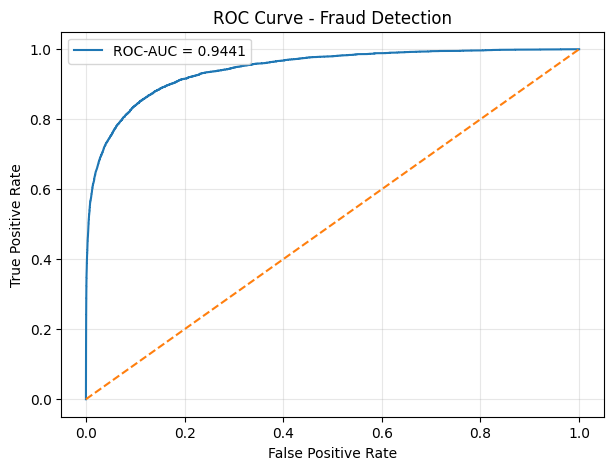

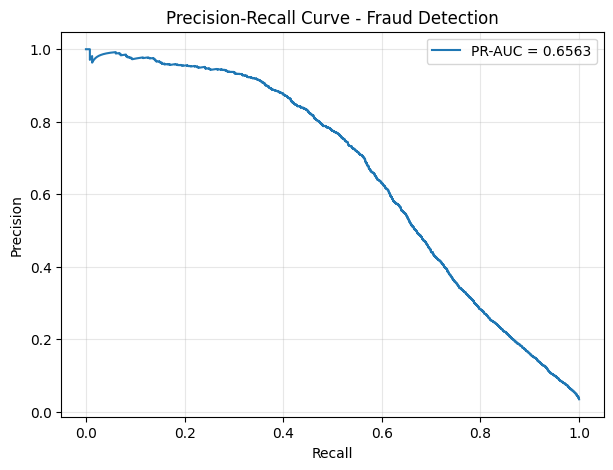

ROC-AUC: 0.9441
PR-AUC : 0.6563


In [23]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Fraud Detection")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Fraud Detection")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("ROC-AUC:", round(roc_auc, 4))
print("PR-AUC :", round(pr_auc, 4))

In [24]:
print("=" * 50)
print("FINAL FRAUD DETECTION MODEL SUMMARY")
print("=" * 50)

print("\nDataset:")
print("Total transactions:", len(df))
print("Total features:", X_train.shape[1])
print("Fraud transactions:", int(y.sum()))
print("Fraud rate:", round(y.mean() * 100, 2), "%")

print("\nData Split:")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nModel Performance:")
print("ROC-AUC:", round(roc_auc, 4))
print("PR-AUC:", round(pr_auc, 4))

print("\nBest Threshold:")
print("Threshold:", best_threshold)
print("Precision:", 0.7039)
print("Recall:", 0.5621)
print("F1 Score:", 0.6251)

print("\nConfusion Matrix:")
print(cm)

print("\nSaved Files:")
print("features.pkl")
print("encoder.pkl")
print("fraud_model.pkl")

print("\n" + "=" * 50)
print("MODEL PIPELINE COMPLETED SUCCESSFULLY")
print("=" * 50)

FINAL FRAUD DETECTION MODEL SUMMARY

Dataset:
Total transactions: 590540
Total features: 46
Fraud transactions: 20663
Fraud rate: 3.5 %

Data Split:
Training samples: 472432
Testing samples: 118108

Model Performance:
ROC-AUC: 0.9441
PR-AUC: 0.6563

Best Threshold:
Threshold: 0.8294
Precision: 0.7039
Recall: 0.5621
F1 Score: 0.6251

Confusion Matrix:
[[112998    977]
 [  1812   2321]]

Saved Files:
features.pkl
encoder.pkl
fraud_model.pkl

MODEL PIPELINE COMPLETED SUCCESSFULLY
